### Data Ingestion

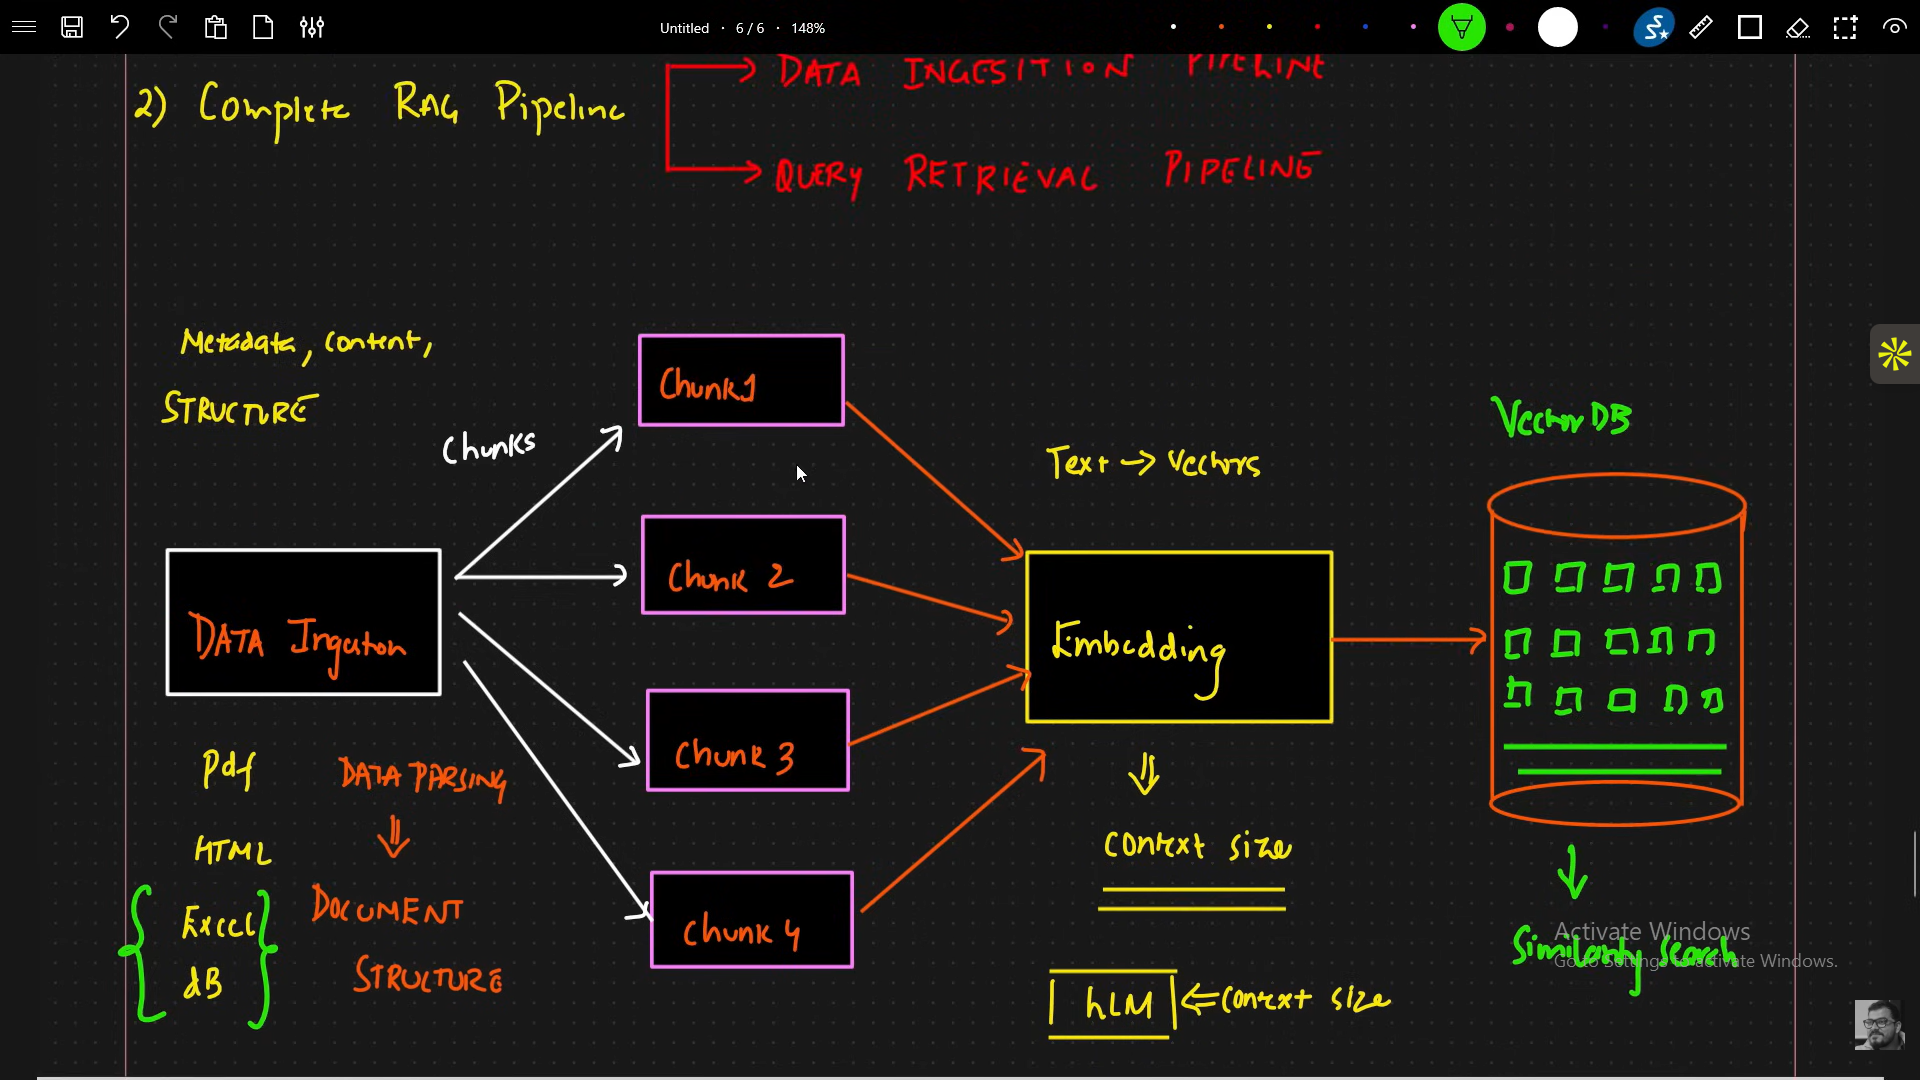

In [1]:
# Document Structure
from langchain_core.documents import Document

In [2]:
doc=Document(
    page_content="This is the content of the document.",
    metadata={
        "source": "example.txt",
        "page_number": 1,
        "author": "Geetanjally",
        "date": "2024-06-01"
    }
)
doc
# metadata can be any dictionary of key-value pairs, and it can be used to store additional information about the document that may be relevant for processing or retrieval.
# metadata can be used to filter documents, provide context for language models, or store any other relevant information that may be useful for downstream tasks.

Document(metadata={'source': 'example.txt', 'page_number': 1, 'author': 'Geetanjally', 'date': '2024-06-01'}, page_content='This is the content of the document.')

In [3]:
## Create a Simple Textfile
import os
os.makedirs("../data/text_files", exist_ok=True)

In [4]:
sample_texts = {
    "../data/text_files/python_intro.txt": """Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has become one of the most popular
programming languages in the world.

Key Features:
- Easy to learn and use
- Extensive standard library
- Cross-platform compatibility
- Strong community support

Applications of Python:
Python is widely used in various domains such as:
- Web development (Django, Flask)
- Data science and analytics (NumPy, Pandas, Matplotlib)
- Machine learning and AI (TensorFlow, PyTorch, Scikit-learn)
- Automation and scripting
- Game development

Why Choose Python?
Python’s simple syntax allows developers to focus more on problem-solving rather than complex code structures.
It supports multiple programming paradigms including procedural, object-oriented, and functional programming.

Conclusion:
Due to its versatility and strong ecosystem, Python continues to grow rapidly and is considered one of the best
languages for beginners as well as experienced developers.
""",

    "../data/text_files/machine_learning.txt": """Machine Learning Basics

Machine learning is a subset of artificial intelligence that enables systems to learn and improve
from experience without being explicitly programmed. It focuses on developing computer programs
that can access data and use it to learn for themselves.

Types of Machine Learning:
1. Supervised Learning: Learning with labeled data
2. Unsupervised Learning: Finding patterns in unlabeled data
3. Reinforcement Learning: Learning through rewards and penalties

Key Concepts:
- Data is the backbone of machine learning
- Models learn patterns from data
- Performance improves with more quality data

Applications:
Machine learning is used in:
- Recommendation systems (Netflix, Amazon)
- Image and speech recognition
- Fraud detection
- Self-driving cars
- Chatbots and virtual assistants

Conclusion:
Machine learning is transforming industries by enabling intelligent decision-making and automation.
"""
}

for file_path,content in sample_texts.items():
    with open(file_path,"w") as f:
        f.write(content)

print("Sample text files created successfully.")

Sample text files created successfully.


In [9]:
# TextLoader

# from langchain.document_loaders import TextLoader

from langchain_community.document_loaders import TextLoader 

loader = TextLoader("../data/text_files/python_intro.txt", encoding="cp1252")
document = loader.load() 
print(document)
# The TextLoader class is used to load text files and create Document objects.
#  It takes the file path and encoding as parameters, reads the content of the file, and returns a list of Document objects containing the page content and metadata.

[Document(metadata={'source': '../data/text_files/python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular\nprogramming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive standard library\n- Cross-platform compatibility\n- Strong community support\n\nApplications of Python:\nPython is widely used in various domains such as:\n- Web development (Django, Flask)\n- Data science and analytics (NumPy, Pandas, Matplotlib)\n- Machine learning and AI (TensorFlow, PyTorch, Scikit-learn)\n- Automation and scripting\n- Game development\n\nWhy Choose Python?\nPython’s simple syntax allows developers to focus more on problem-solving rather than complex code structures.\nIt supports multiple programming paradigms including procedural, object-oriented, and functional 

In [ ]:
#Directory loader
from langchain_community.document_loaders import DirectoryLoader

#Load all the text files from the directory
dir_loader = DirectoryLoader(
    "../data/text_files",
    glob="**/*.txt", ## Pattern to match files
    loader_cls = TextLoader, #loader class to use for loading files
    loader_kwargs={"encoding":'cp1252'} , # or 'latin1' if needed, #additional arguments to pass to the loader class
    show_progress=False
)

documents = dir_loader.load()
documents

[Document(metadata={'source': '..\\data\\text_files\\machine_learning.txt'}, page_content='Machine Learning Basics\n\nMachine learning is a subset of artificial intelligence that enables systems to learn and improve\nfrom experience without being explicitly programmed. It focuses on developing computer programs\nthat can access data and use it to learn for themselves.\n\nTypes of Machine Learning:\n1. Supervised Learning: Learning with labeled data\n2. Unsupervised Learning: Finding patterns in unlabeled data\n3. Reinforcement Learning: Learning through rewards and penalties\n\nKey Concepts:\n- Data is the backbone of machine learning\n- Models learn patterns from data\n- Performance improves with more quality data\n\nApplications:\nMachine learning is used in:\n- Recommendation systems (Netflix, Amazon)\n- Image and speech recognition\n- Fraud detection\n- Self-driving cars\n- Chatbots and virtual assistants\n\nConclusion:\nMachine learning is transforming industries by enabling intel

In [ ]:
# For PDF files.
from langchain_community.document_loaders import PyPDFLoader,PyMuPDFLoader

dir_loader = DirectoryLoader(
    "../data/pdf",
    glob="**/*.pdf",
    loader_cls=PyMuPDFLoader,
    show_progress=False
)
pdf_documents = dir_loader.load()
pdf_documents

[Document(metadata={'producer': 'macOS Version 10.14.2 (Build 18C54) Quartz PDFContext', 'creator': 'Pages', 'creationdate': "D:20190103112422Z00'00'", 'source': '..\\data\\pdf\\390 - 73.Queue-LL.pdf', 'file_path': '..\\data\\pdf\\390 - 73.Queue-LL.pdf', 'total_pages': 2, 'format': 'PDF 1.3', 'title': '120. Queue LL', 'author': '', 'subject': '', 'keywords': '', 'moddate': "D:20190103112422Z00'00'", 'trapped': '', 'modDate': "D:20190103112422Z00'00'", 'creationDate': "D:20190103112422Z00'00'", 'page': 0}, page_content='Queue using Linked List\n#include <stdio.h>\n#include <stdlib.h>\nstruct Node\n{\n    int data;\n    struct Node *next;\n    \n}*front=NULL,*rear=NULL;\nvoid enqueue(int x)\n{\n    struct Node *t;\n    t=(struct Node*)malloc(sizeof(struct Node));\n    if(t==NULL)\n        printf("Queue is FUll\\n");\n    else\n    {\n        t->data=x;\n        t->next=NULL;\n        if(front==NULL)\n            front=rear=t;\n        else\n        {\n            rear->next=t;\n         

In [ ]:
type(pdf_documents[0])

langchain_core.documents.base.Document

## Embedding And VectorStoreDB

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
import chromadb.config 
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""

    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        """
        Initialize the embedding manager
        
        Args:
            model_name: Hugging Face model name for sentence transformer"""
        self.model_name = model_name
        self.model = None
        self._load_model()
        
    def _load_model(self):
        """Load the sentence transformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}...")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise e
        
    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """Generate embeddings for a list of documents

        Args:
            texts: List of document texts to embed

        Returns:
            numpy array of embeddings with shape (num_texts, embedding_dim)"""
        if self.model is None:
            raise ValueError("Embedding model is not loaded.")
        try:
            print(f"Generating embeddings for {len(texts)} documents...")
            embeddings = self.model.encode(texts, show_progress_bar=True)
            print("Embeddings generated successfully.")
            return np.array(embeddings)
        except Exception as e:
            print(f"Error generating embeddings: {e}")
            raise e


## Initializa the smbedding manager

embedding_manager = EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2...


f:\Placements\NLP\2_RAG\0_DataIngestion\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1816.94it/s]


Model loaded successfully. Embedding dimension: 384


C:\Users\HP\AppData\Local\Temp\ipykernel_14232\2968499620.py:19: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")


## VectorStoreDB

In [ ]:
import os

class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""

    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection to use
            persist_directory: Directory to persist the ChromaDB database
        """

        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize the ChromaDB client and collection"""
        try:
            # Create Persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)

            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "Collection of PDF document embeddings"}
            )

            print(f"Vector store initialized, Collection: {self.collection_name}" )
            print(f"Existing documents in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise 
    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store

        Args:
            documents: List of Langchain document objects (e.g., Document instances)
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents and embeddings must match.")
        
        print(f"Adding {len(documents)} documents to the vector store...")

        #Prepare data for chromaDB
        ids=[]
        metadatas=[]
        documents_text=[]
        embeddings_list = []

        for i,(doc,embedding) in enumerate(zip(documents, embeddings)):
            # Generate a unique ID for each document
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)

            # Prepare metadata
            metadata=dict(doc.metadata)
            metadata['doc_index']=i
            metadata['content_length']=len(doc.page_content)
            metadatas.append(metadata)

            #Document content
            documents_text.append(doc.page_content)

            #Embedding
            embeddings_list.append(embedding.tolist()) # Convert numpy array to list for JSON serialization
        try:
            self.collection.add(
                ids=ids,
                metadatas=metadatas,
                documents=documents_text,
                embeddings=embeddings_list
            )
            print(f"Successfully added {len(documents)} documents to vector store.")
            print(f"Total documents in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise 

vectorstore = VectorStore()
vectorstore

Vector store initialized, Collection: pdf_documents
Existing documents in collection: 0


In [6]:
# The variable `chunks` is not defined in this notebook.
# Define `chunks` first, for example by splitting documents into chunks,
# or use an existing variable such as `documents` or `vectorstore`.
print("Define 'chunks' before using it.")

Define 'chunks' before using it.
